In [1]:
%load_ext autoreload
%autoreload 2
import os
from functools import partial
from typing import Callable, Generator, Optional

os.environ["EQX_ON_ERROR"] = "nan"
os.environ["XLA_FLAGS"] = "--xla_disable_hlo_passes=multi_output_fusion"
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import spec_optimization as opt_spec
from ax import Client
from diffrax import Tsit5, Heun
from jaxtyping import PyTree
from sat_dataloader import (
    SATDataloader,
    sat_3var7clauses_data,
    sat_from_cnf_dir,
    sat_random_clauses,
)
from sat_loss import (
    approx_sat_loss,
    loss_w_sol,
    phase_to_approx_sat_loss,
    phase_to_energy,
    phase_to_sat_clause_rate,
    system_energy_loss,
)
from sat_parser import parser
from sat_utils import (
    BLUE_PHASE,
    FALSE_PHASE,
    TRUE_PHASE,
    create_3sat_graph,
    create_3sat_graph_v2,
    flatten_nw_stateful_oscillators,
    param_keys_v1,
    param_keys_v2,
    parameters_v1,
    parameters_v2,
)


import wandb
from ark.optimization.base_module import BaseAnalogCkt, TimeInfo
from ark.optimization.opt_compiler import OptCompiler
from ark.specification.trainable import Trainable, TrainableMgr
# jax.config.update("jax_compilation_cache_dir", "jax_cache")
# jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
# jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)

jax.config.update("jax_enable_x64", True)

In [32]:
N_VARS = 20
N_CLAUSES = 91
BZ = 1
T1 = 100
DT0 = 0.01
create_graph = create_3sat_graph_v2
trainable_mgr = TrainableMgr()
# time_points = jnp.arange(0, T1, 0.1)
time_points = jnp.array([i for i in range(0, int(T1 + 1), 2)])
time_info = TimeInfo(
    t0=0.0,
    t1=T1,
    dt0=DT0,
    saveat=time_points,
)
lock_anneal_schedule = [jnp.tanh(1 * jnp.cos(jnp.pi * t)) / 2 + 0.4 for t in time_points]
# lock_anneal_schedule = [10* t for t in time_points]
INITIAL_STATE = "random"



In [33]:
np.random.seed(0)

sat_probs = sat_from_cnf_dir(dir_path="uf20-91")
# sat_probs = sat_random_clauses(n_vars=N_VARS, n_clauses=N_CLAUSES, n_prob=10)
n_vars, n_clauses = N_VARS, N_CLAUSES
graph, nw = create_graph(
    n_vars=n_vars, n_clauses=n_clauses, trainable_mgr=trainable_mgr
)
sat_solutions = None

# flatten the var_oscs
n_vars = len(nw.var_oscs)
nodes_flat = flatten_nw_stateful_oscillators(nw)
ckt_class = OptCompiler().compile(
    prog_name="3sat",
    cdg=graph,
    cdg_spec=opt_spec.obc_spec,
    trainable_mgr=trainable_mgr,
    readout_nodes=nodes_flat,
    normalize_weight=False,
    do_clipping=True,
    vectorize=True,
)

init_weight = trainable_mgr.get_initial_vals()
model: BaseAnalogCkt = ckt_class(
    init_trainable=init_weight,
    is_stochastic=True,
    solver=Tsit5(),
)
nw.set_var_clause_cpls_args_idx(model=model)
dataloader = SATDataloader(INITIAL_STATE, BZ, sat_probs, nw, sat_solutions)



/var/folders/zv/1cq_05k97dl9b9_kf_drhmdr0000gp/T/ipykernel_22229/2343916835.py:45: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(min_lock - 0.1 * (max_lock - min_lock), min_lock + 4 * (max_lock - min_lock))


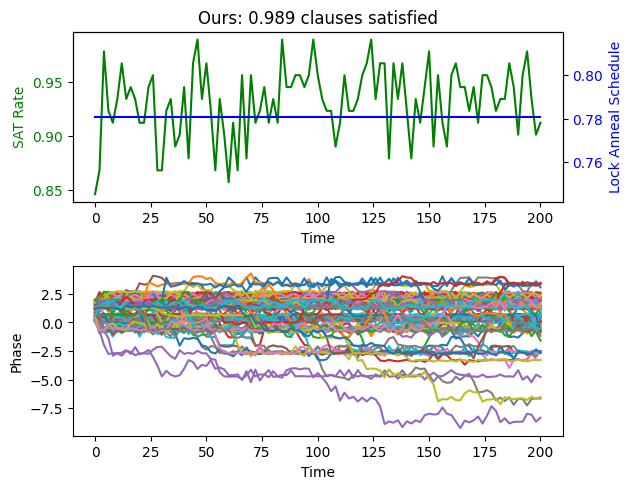

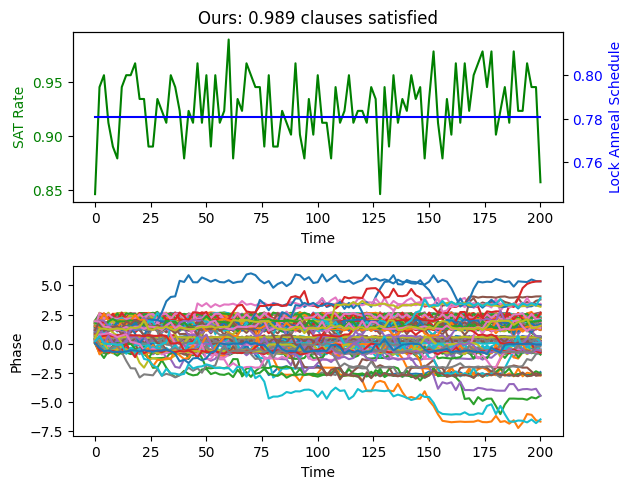

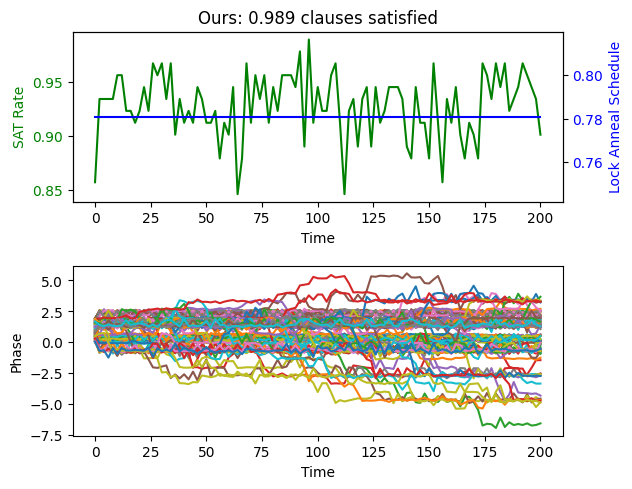

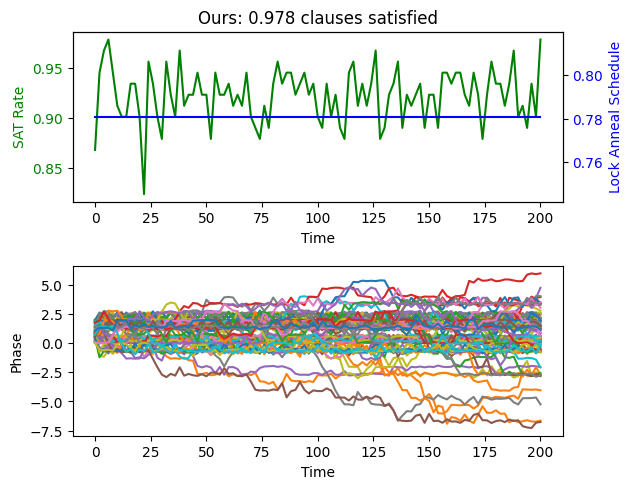

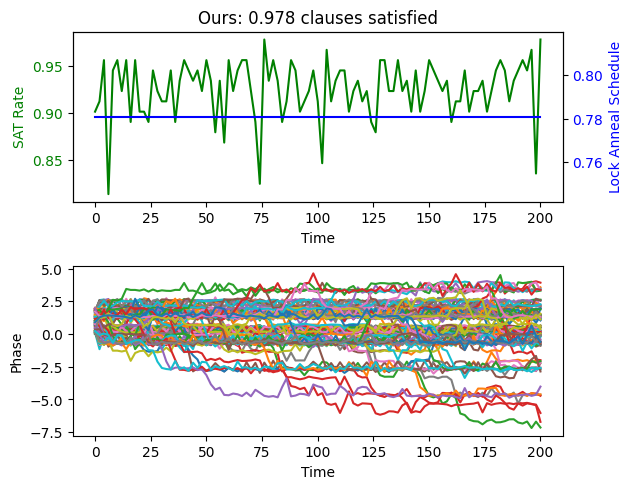

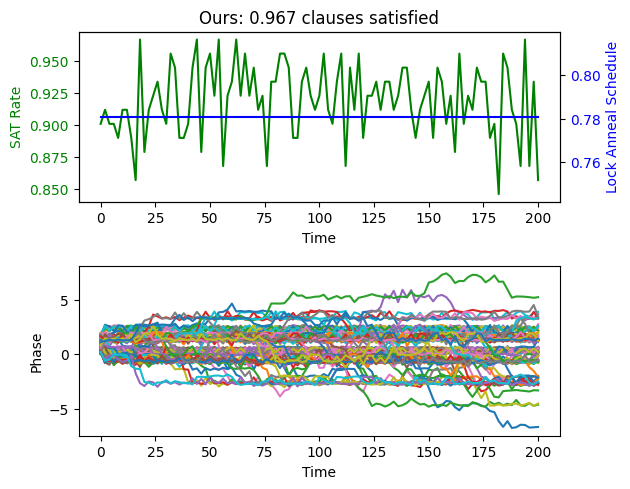

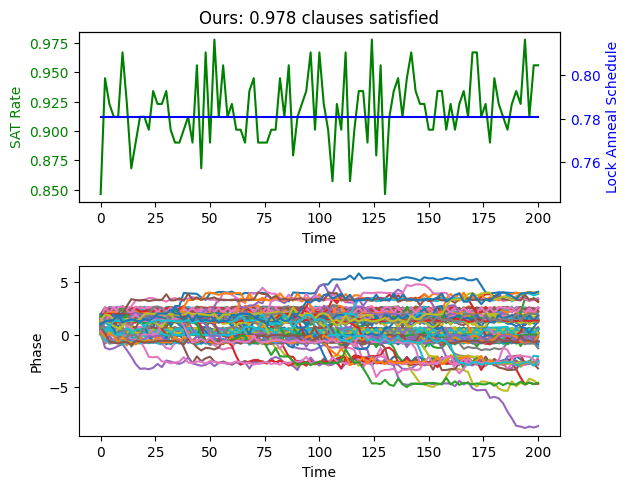

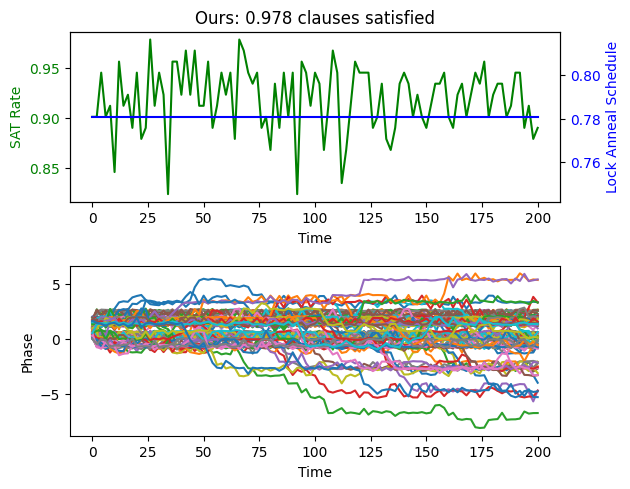

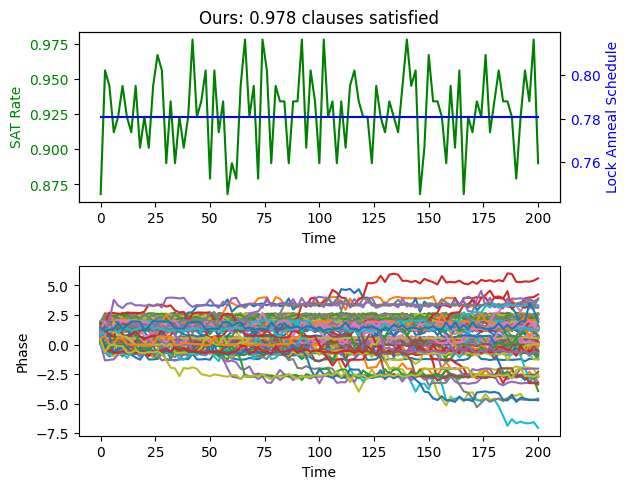

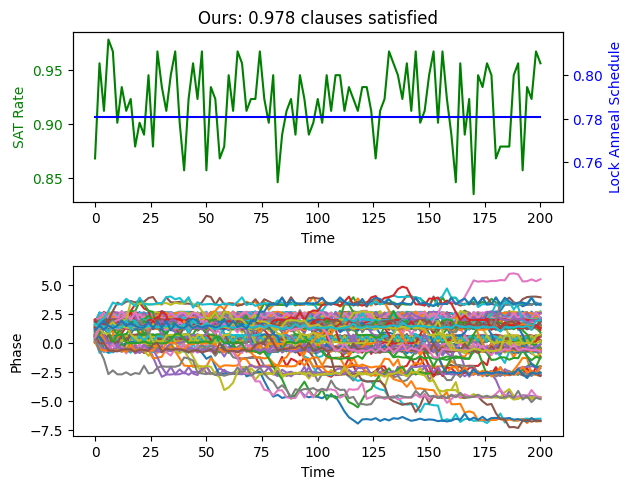

In [25]:
def simulate(
    model: BaseAnalogCkt,
    init_states: jax.Array,
    switches: jax.Array,
    sol: jax.Array,
    adj_matrix: jax.Array,
    n_vars: int,
    problems: jax.Array,
    trasform_mats: jax.Array,
    noise_seed: jax.Array,
    time_info: TimeInfo,
) -> tuple[jax.Array, jax.Array]:
    # Get the output of the model, the first n_var output is a 1D array of shape (2n,) representing
    # the phase values of -var[0], var[0], -var[1], var[1], -var[2], var[2], ..., -var[n], var[n]
    y_raw = jax.vmap(model, in_axes=(None, 0, 0, None, 0))(
        time_info, init_states, switches, 0, noise_seed
    )

    return y_raw

for step, data in zip(range(10), dataloader):
    phase_raw = simulate(model, *data, time_info=time_info)
    adj_mats, n_vars, probs, transform_mats = data[3:7]
    bz, n_time_points, n_vars = phase_raw.shape
    energy, sat_rate = [], []
    for t in range(n_time_points):
        phase_t = phase_raw[:, t:t+1, :]
        sat_rate.append(phase_to_sat_clause_rate(n_vars, phase_t, probs))
    
    ratio_satisfied = jnp.array(sat_rate).max(axis=0)
    
    # plot the sat_rate and anneal schedule on the dual y-axis
    fig, ax1 = plt.subplots(ncols=1, nrows=2)
    ax2 = ax1[0].twinx()
    ax1[0].set_title(f"Ours: {ratio_satisfied[0]:.3f} clauses satisfied")
    ax1[0].plot(time_points, jnp.array(sat_rate),
                color='g', label='SAT Rate')
    ax2.plot(time_points, jnp.array(lock_anneal_schedule),
                color='b', label='Lock Anneal Schedule')
    ax1[0].set_xlabel('Time')
    ax1[0].set_ylabel('SAT Rate', color='g')
    ax2.set_ylabel('Lock Anneal Schedule', color='b')
    # set the y-limits so that annealing schedule only occupies bottom 1/4 of the plot
    max_lock, min_lock = max(lock_anneal_schedule), min(lock_anneal_schedule)
    ax2.set_ylim(min_lock - 0.1 * (max_lock - min_lock), min_lock + 4 * (max_lock - min_lock))
    ax1[0].tick_params(axis='y', labelcolor='g')
    ax2.tick_params(axis='y', labelcolor='b')
    fig.tight_layout()

    # plot the phases of all oscillators
    for i in range(phase_raw.shape[-1]):
        ax1[1].plot(time_points, phase_raw[0, :, i])
    ax1[1].set_xlabel('Time')
    ax1[1].set_ylabel('Phase')
    plt.show()


In [34]:
from sat_ucb3or_baseline import SATDataloader as ucb3orDataloader
from sat_ucb3or_baseline import OscNetwork, n_sat_clauses, sat_clause_rate_score


/var/folders/zv/1cq_05k97dl9b9_kf_drhmdr0000gp/T/ipykernel_22229/3200562304.py:53: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(min_lock - 0.1 * (max_lock - min_lock), min_lock + 4 * (max_lock - min_lock))


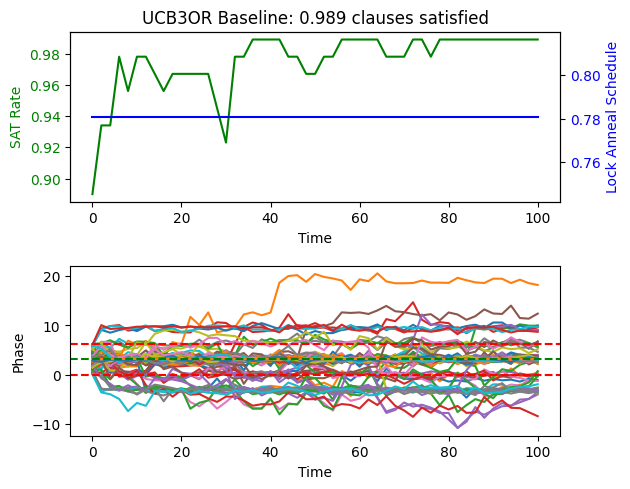

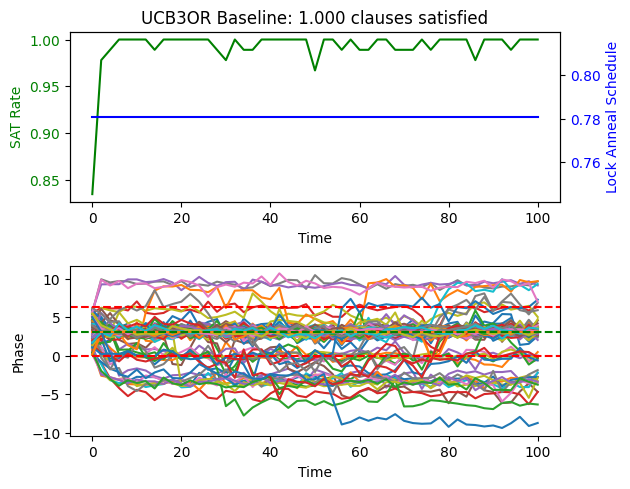

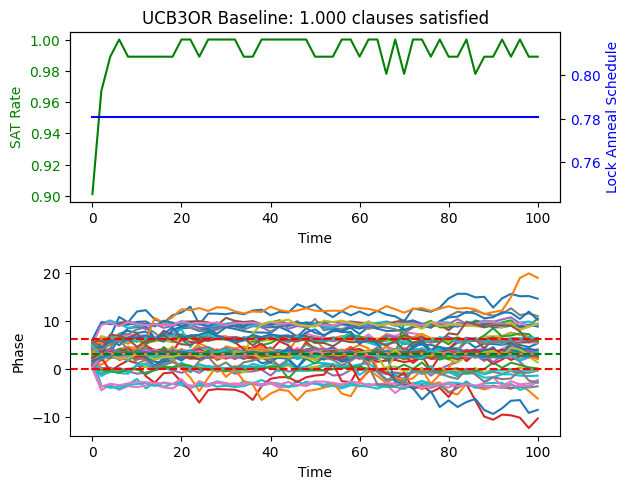

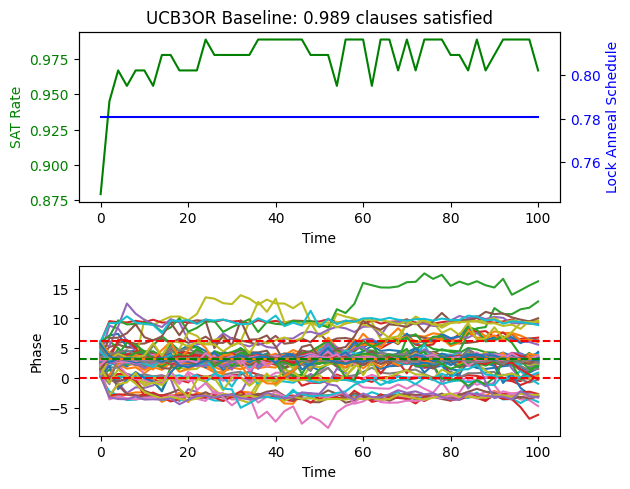

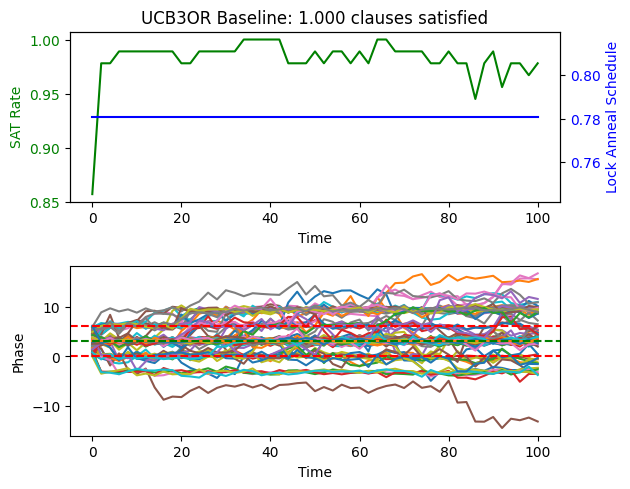

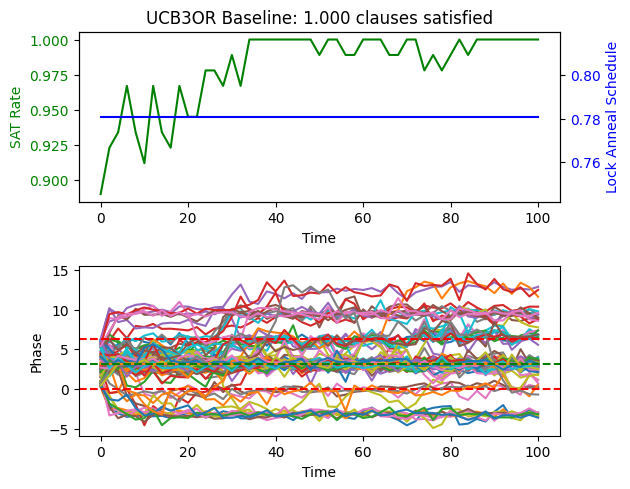

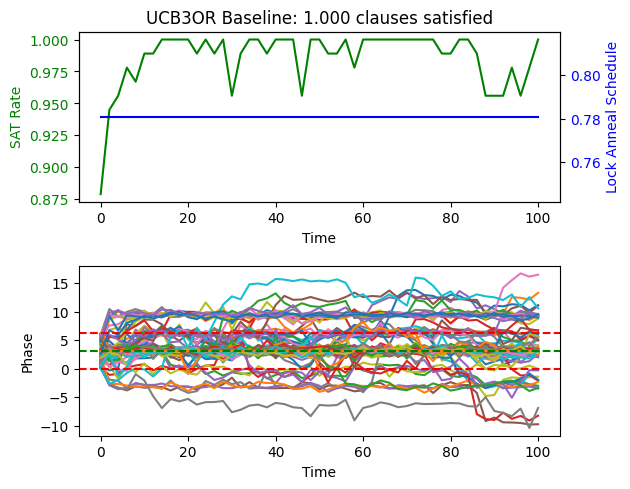

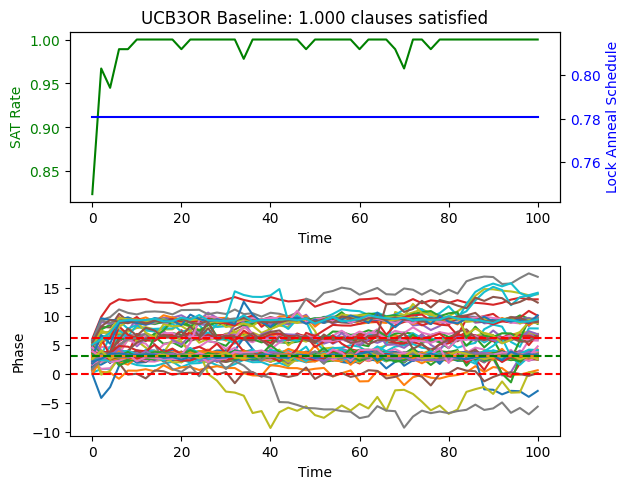

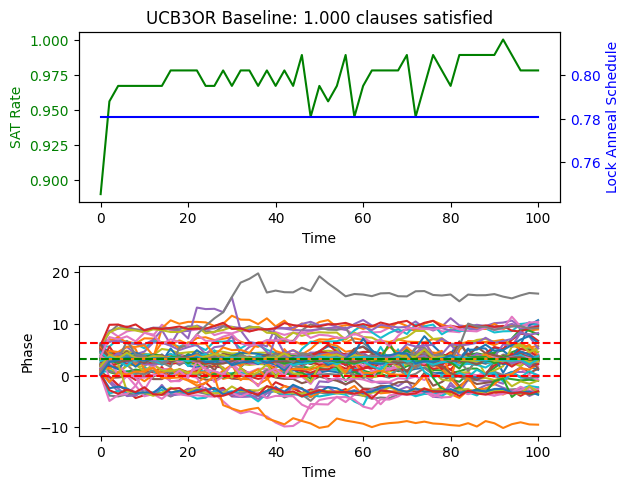

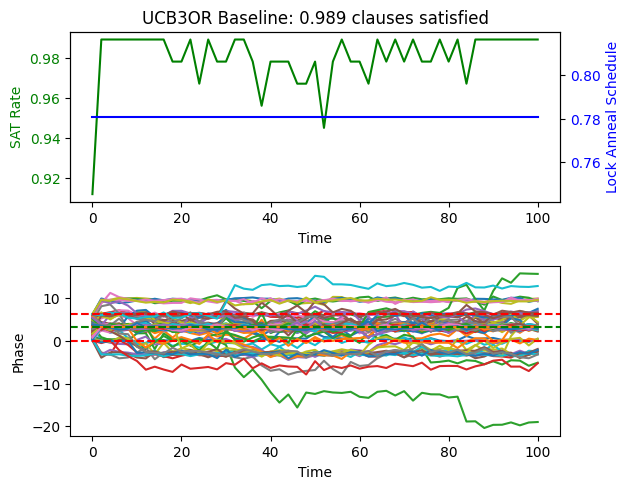

In [35]:
dataloader = ucb3orDataloader(batch_size=1,sat_probs=sat_probs, n_vars=n_vars)

model = OscNetwork()
TRUE_PHASE, FALSE_PHASE = jnp.pi, 0.0

for step, data in zip(range(10), dataloader):
    ratio_satisfied, phase_raw = sat_clause_rate_score(model, *data, time_info=time_info)

    problems = data[1]

    assignment_phase = phase_raw[:, :, :n_vars]
    # Map the variable phases to boolean assignments
    modular_phase = jnp.mod(assignment_phase, 2.0 * jnp.pi)
    threshold = (TRUE_PHASE - FALSE_PHASE) / 2
    bool_assignments = jnp.array(
        [jnp.abs(phase - TRUE_PHASE) < threshold for phase in modular_phase]
    )

    # Calculate the number of satisfied clauses for each problem
    sat_rate = []
    n_sat_clause_list = []
    for clauses, assignments_in_run in zip(problems, bool_assignments):
        # Count the number of satisfied clauses for each run
        # Record the assignment that satisfies the most clauses
        best_n_sat_clause = 0
        for assignment in assignments_in_run:
            best_n_sat_clause = max(
                best_n_sat_clause, n_sat_clauses(clauses, assignment)
            )
            sat_rate.append(n_sat_clauses(clauses, assignment) / len(clauses))
        n_sat_clause_list.append(best_n_sat_clause)

    # Convert the list to a jax array
    n_satisfied_clauses = jnp.array(n_sat_clause_list)

    # Calculate the ratio of satisfied clauses
    n_clauses = jnp.array([len(prob) for prob in problems])
    ratio_satisfied = n_satisfied_clauses / n_clauses

    # plot the sat_rate and anneal schedule on the dual y-axis
    fig, ax1 = plt.subplots(ncols=1, nrows=2)
    ax2 = ax1[0].twinx()
    ax1[0].set_title(f"UCB3OR Baseline: {ratio_satisfied[0]:.3f} clauses satisfied")
    ax1[0].plot(time_points, jnp.array(sat_rate),
                color='g', label='SAT Rate')
    ax2.plot(time_points, jnp.array(lock_anneal_schedule),
                color='b', label='Lock Anneal Schedule')
    ax1[0].set_xlabel('Time')
    ax1[0].set_ylabel('SAT Rate', color='g')
    ax2.set_ylabel('Lock Anneal Schedule', color='b')
    # set the y-limits so that annealing schedule only occupies bottom 1/4 of the plot
    max_lock, min_lock = max(lock_anneal_schedule), min(lock_anneal_schedule)
    ax2.set_ylim(min_lock - 0.1 * (max_lock - min_lock), min_lock + 4 * (max_lock - min_lock))
    ax1[0].tick_params(axis='y', labelcolor='g')
    ax2.tick_params(axis='y', labelcolor='b')
    fig.tight_layout()

    # plot the phases of all oscillators
    for i in range(phase_raw.shape[-1]):
        ax1[1].plot(time_points, phase_raw[0, :, i])
    ax1[1].set_xlabel('Time')
    ax1[1].set_ylabel('Phase')
    # Plot horizontal lines at 0, pi, and 2pi
    ax1[1].axhline(y=0, color='r', linestyle='--')
    ax1[1].axhline(y=jnp.pi, color='g', linestyle='--')
    ax1[1].axhline(y=2 * jnp.pi, color='r', linestyle='--')
    plt.show()


In [ ]:
import pandas as pd

dataset = ["10var45clauses", "20var91clauses"]
for d in dataset:
    file = f"{d}.csv"
    df = pd.read_csv(file)



    steps = df['step']

    sat_rate_nonstochastic, sat_rate_stochastic = [], []
    best_sat_rate_nonstochastic, best_sat_rate_stochastic = [], []
    for col in df.columns:
        if col.endswith("sat_rate"):
            sat_rate = df[col].to_numpy()
            best_sat_rate = np.maximum.accumulate(sat_rate)
            if "stochastic" in col:
                sat_rate_stochastic.append(sat_rate)
                best_sat_rate_stochastic.append(best_sat_rate)
            else:
                sat_rate_nonstochastic.append(sat_rate)
                best_sat_rate_nonstochastic.append(best_sat_rate)

    # plot the best_sat_rate (min, mean, max) over steps
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    for rates, best_rates, label in [
        (sat_rate_nonstochastic,best_sat_rate_nonstochastic, "Non-stochastic"),
        (sat_rate_stochastic,best_sat_rate_stochastic, "Stochastic"),
    ]:
        rates = np.array(rates)
        mean_rate = np.mean(rates, axis=0)
        min_rate = np.min(rates, axis=0)
        max_rate = np.max(rates, axis=0)
        axs[0].plot(steps, mean_rate, label=f"{label} Mean")
        axs[0].fill_between(steps, min_rate, max_rate, alpha=0.2)

        best_rates = np.array(best_rates)
        mean_best_rate = np.mean(best_rates, axis=0)
        min_best_rate = np.min(best_rates, axis=0)
        max_best_rate = np.max(best_rates, axis=0)
        axs[1].plot(steps, mean_best_rate, label=f"{label} Mean")
        axs[1].fill_between(steps, min_best_rate, max_best_rate, alpha=0.2)

    axs[0].set_xlabel("Steps")
    axs[0].set_ylabel("% satisfied clauses")
    axs[0].set_title("SAT Rate")
    axs[0].legend()

    axs[1].set_xlabel("Steps")
    axs[1].set_ylabel("% satisfied clauses")
    axs[1].set_title("Best SAT Rate")
    axs[1].legend()

    plt.suptitle(d)
    plt.tight_layout()